## **Case Study: Intraday Momentum Strategy for SPY**
### Aleksandar Milosavljevic

## Step 1: setup and data pre-processing
- import the neccessary libraries
- load historical data.
- clean timestamps and filtering for standard us market hours (09:30 - 16:00).
- feature engineering (e.g., minute_index, anchored vwap).
- split the dataset into in-sample (train) and out-of-sample (test) periods.

In [1]:
import alpaca
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
import pandas as pd
import numpy as np
from datetime import datetime
import datetime as dt
import matplotlib.pyplot as plt
import os

In [2]:
API_KEY = "PKRJ35STTBRTJYRCOPXMAPOPNV"
SECRET_KEY = "2g72R4nLL4jE3dKmNDCRX7qMK4dsi6RvG8zq3S5CfZZ9"

client = StockHistoricalDataClient(API_KEY, SECRET_KEY)

request = StockBarsRequest(
    symbol_or_symbols="SPY",
    timeframe=TimeFrame.Minute,
    start=datetime(2016, 1, 4),
    end=datetime(2025, 12, 31),
)

bars = client.get_stock_bars(request)
df = bars.df
df = df.reset_index()

df.head()
df.tail()
df.info()

#save the time series as csv
df.to_csv("spy_data.csv", index=False)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985051 entries, 0 to 1985050
Data columns (total 9 columns):
 #   Column       Dtype              
---  ------       -----              
 0   symbol       object             
 1   timestamp    datetime64[ns, UTC]
 2   open         float64            
 3   high         float64            
 4   low          float64            
 5   close        float64            
 6   volume       float64            
 7   trade_count  float64            
 8   vwap         float64            
dtypes: datetime64[ns, UTC](1), float64(7), object(1)
memory usage: 136.3+ MB


In [3]:
# # read the data frame (same as fetched from API)
# if not os.path.exists("spy_data.csv"):
#     raise FileNotFoundError("Please ensure 'spy_data.csv' is in the directory.")
# df = pd.read_csv("spy_data.csv")

In [4]:
# inspect the columns of the dataset
df.columns.tolist()

['symbol',
 'timestamp',
 'open',
 'high',
 'low',
 'close',
 'volume',
 'trade_count',
 'vwap']

In [5]:
# save the initial dataframe to not fetch it every time
df_initial = df.copy()
# df = df_initial.copy()

In [6]:
# convert to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp'] = df['timestamp'].dt.tz_convert('America/New_York')

In [7]:
# use only trading hours
df = df[
    (df['timestamp'].dt.time >= pd.to_datetime("09:30").time()) &
    (df['timestamp'].dt.time <= pd.to_datetime("15:59").time())
]

In [8]:
# create date column to be able to group by date
df['date'] = df['timestamp'].dt.date

In [9]:
# inspect the df
df[df['date'] == df['date'].unique()[0]].head(10)

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap,date
269,SPY,2016-01-04 09:30:00-05:00,200.490,200.530,200.260,200.4100,2498430.0,4672.0,200.460265,2016-01-04
270,SPY,2016-01-04 09:31:00-05:00,200.405,200.436,200.205,200.3151,850216.0,3744.0,200.281888,2016-01-04
271,SPY,2016-01-04 09:32:00-05:00,200.310,200.460,200.310,200.4000,642808.0,2430.0,200.390525,2016-01-04
272,SPY,2016-01-04 09:33:00-05:00,200.400,200.410,200.200,200.2700,812281.0,3288.0,200.284406,2016-01-04
273,SPY,2016-01-04 09:34:00-05:00,200.270,200.270,200.020,200.0800,835983.0,3123.0,200.109604,2016-01-04
274,SPY,2016-01-04 09:35:00-05:00,200.070,200.300,200.070,200.2400,826828.0,3733.0,200.203064,2016-01-04
275,SPY,2016-01-04 09:36:00-05:00,200.230,200.310,200.180,200.2100,805883.0,3542.0,200.243295,2016-01-04
276,SPY,2016-01-04 09:37:00-05:00,200.210,200.430,200.180,200.3846,589938.0,2749.0,200.297803,2016-01-04
277,SPY,2016-01-04 09:38:00-05:00,200.390,200.411,200.190,200.2200,794617.0,3310.0,200.298027,2016-01-04
278,SPY,2016-01-04 09:39:00-05:00,200.220,200.280,200.110,200.2450,1251300.0,3304.0,200.198715,2016-01-04


In [10]:
# inspect timespan
print(df['timestamp'].min())
print(df['timestamp'].max())

2016-01-04 09:30:00-05:00
2025-12-30 15:59:00-05:00


In [11]:
#  number of days
print("Total days:", df['date'].nunique())

#  bars per day
bars_per_day = df.groupby('date').size()
print(bars_per_day.describe())

# check min and max bars per day
print("Min bars:", bars_per_day.min())
print("Max bars:", bars_per_day.max())

Total days: 2513
count    2513.000000
mean      389.557501
std         4.985087
min       278.000000
25%       390.000000
50%       390.000000
75%       390.000000
max       390.000000
dtype: float64
Min bars: 278
Max bars: 390


In [12]:
####### remove non-full trading days#########
# count bars per day
bars_per_day = df.groupby('date').size()

# keep only full days 
full_days = bars_per_day[bars_per_day == 390].index

# filter dataframe
df = df[df['date'].isin(full_days)].copy()

# check 
df.groupby('date').size().describe()


count    2484.0
mean      390.0
std         0.0
min       390.0
25%       390.0
50%       390.0
75%       390.0
max       390.0
dtype: float64

In [13]:
#### create minute index ###
df = df.sort_values(['date', 'timestamp'])
df['minute_index'] = df.groupby('date').cumcount()

sample_day = df['date'].iloc[0]
df[df['date'] == sample_day].tail()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap,date,minute_index
654,SPY,2016-01-04 15:55:00-05:00,200.590,200.8125,200.59,200.710,1378646.0,5118.0,200.707472,2016-01-04,385
655,SPY,2016-01-04 15:56:00-05:00,200.710,200.7700,200.57,200.580,996152.0,3994.0,200.682564,2016-01-04,386
656,SPY,2016-01-04 15:57:00-05:00,200.575,200.7900,200.57,200.780,1351581.0,4900.0,200.700849,2016-01-04,387
657,SPY,2016-01-04 15:58:00-05:00,200.780,200.8900,200.68,200.695,1209722.0,4345.0,200.813108,2016-01-04,388
658,SPY,2016-01-04 15:59:00-05:00,200.690,201.0300,200.69,200.990,3468633.0,9298.0,200.907564,2016-01-04,389


In [14]:
# calculate cumulative vwap, needed for the refined trailing stop
df['price_volume'] = df['vwap'] * df['volume'] 
df['cum_price_volume'] = df.groupby('date')['price_volume'].cumsum()
df['cum_volume'] = df.groupby('date')['volume'].cumsum()
   
df['vwap_anchored'] = df['cum_price_volume'] / df['cum_volume']

df[df['date'] == sample_day].tail()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap,date,minute_index,price_volume,cum_price_volume,cum_volume,vwap_anchored
654,SPY,2016-01-04 15:55:00-05:00,200.590,200.8125,200.59,200.710,1378646.0,5118.0,200.707472,2016-01-04,385,2.767046e+08,3.902859e+10,195504636.0,199.630003
655,SPY,2016-01-04 15:56:00-05:00,200.710,200.7700,200.57,200.580,996152.0,3994.0,200.682564,2016-01-04,386,1.999103e+08,3.922850e+10,196500788.0,199.635339
656,SPY,2016-01-04 15:57:00-05:00,200.575,200.7900,200.57,200.780,1351581.0,4900.0,200.700849,2016-01-04,387,2.712635e+08,3.949976e+10,197852369.0,199.642618
657,SPY,2016-01-04 15:58:00-05:00,200.780,200.8900,200.68,200.695,1209722.0,4345.0,200.813108,2016-01-04,388,2.429280e+08,3.974269e+10,199062091.0,199.649731
658,SPY,2016-01-04 15:59:00-05:00,200.690,201.0300,200.69,200.990,3468633.0,9298.0,200.907564,2016-01-04,389,6.968746e+08,4.043957e+10,202530724.0,199.671273


In [15]:
# Split into train/test : 80%/20%

all_days = pd.Index(sorted(df['date'].unique()))

split_idx = int(0.8 * len(all_days))    
train_days = all_days[:split_idx]
test_days  = all_days[split_idx:]

df_train = df[df['date'].isin(train_days)].copy()
df_test  = df[df['date'].isin(test_days)].copy()

## Step 2: strategy logic and signal construction
Tthis phase defines the mathematical core of the backtest
- build the noise area and boundaries.
- define entry rules, semi-hourly timing and stop-loss triggers.
- implement trailing stops based on vwap and band boundaries.

We define 3 main functions for implementing the strategy:
- function **generate_signals()**
- function **execute_strategy()**
- function **calculate_pnl()**

In [16]:
# Function: generate_signals(df, lookback = 14, vm)
# purpose: constructs the noise area to identify abnormal demand/supply imbalances.
#          bounds are calculated as:
#          Upper Bound = max(Open_t, Close_t-1) * (1 + VM * sigma) 
#          Lower Bound = min(Open_t, Close_t-1) * (1 - VM * sigma) 
#
# Inputs:
#   -- df       : dataframe containing minute level OHLCV data with 'date' and 'minute_index'
#   -- lookback : days used to compute the average intraday movement. Default is 14
#   -- vm       : Volatility Multiplier to adjust noise area width. Default is 14
#
# Output:
#   -- df       : datagrame with computed boundaries and historical intraday volatility (sigma)


def generate_signals(df, vm,lookback = 14, ):
    # sort by date and time
    df = df.sort_values(['date', 'minute_index'])

    # calculates the open price for each trading day and maps that
    #  value to every single minute (row) of that same day
    df['open_price'] = df.groupby('date')['open'].transform('first')

    # compute intraday return from open and its absolute value
    df['ret_from_open'] = df['close'] / df['open_price'] - 1
    df['abs_move'] = df['ret_from_open'].abs()

    # compute the sigma
    df['sigma'] = (
        df.groupby('minute_index')['abs_move'].transform(lambda x: x.shift(1).rolling(lookback).mean())
    )

    #
    # use the previous day's close to adjust boundaries for overnight gaps.
    daily_close = df.groupby('date')['close'].last()
    prev_close_map = daily_close.shift(1)
    df['prev_close'] = df['date'].map(prev_close_map)

    # noise area Boundaries
    # upper: max of open/prev_close + (VM * Sigma)
    # lower: min of open/prev_close - (VM * Sigma)
    df['base_upper'] = df[['open_price', 'prev_close']].max(axis=1)
    df['base_lower'] = df[['open_price', 'prev_close']].min(axis=1)

    df['upper_bound'] = df['base_upper'] * (1 + vm * df['sigma'])
    df['lower_bound'] = df['base_lower'] * (1 - vm * df['sigma'])


    # remove rows where we do not have enough lookback data yet
    return df.dropna(subset=['sigma', 'prev_close']).copy()

In [17]:
# use the function
df_train_signals = generate_signals(df = df_train, lookback = 14, vm = 1)

In [18]:
df_train_signals.head(5)

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap,date,...,vwap_anchored,open_price,ret_from_open,abs_move,sigma,prev_close,base_upper,base_lower,upper_bound,lower_bound
12356,SPY,2016-01-25 09:30:00-05:00,189.93,190.02,189.81,189.8828,1177720.0,2897.0,189.933852,2016-01-25,...,189.933852,189.93,-0.000249,0.000249,0.000647,190.49,190.49,189.93,190.613269,189.807093
12357,SPY,2016-01-25 09:31:00-05:00,189.89,190.02,189.83,189.9800,669008.0,3039.0,189.936956,2016-01-25,...,189.934976,189.93,0.000263,0.000263,0.001182,190.49,190.49,189.93,190.715110,189.705552
12358,SPY,2016-01-25 09:32:00-05:00,189.99,190.12,189.80,189.8600,1285493.0,4630.0,189.931426,2016-01-25,...,189.933519,189.93,-0.000369,0.000369,0.001311,190.49,190.49,189.93,190.739640,189.681094
12359,SPY,2016-01-25 09:33:00-05:00,189.85,190.01,189.79,189.9750,594235.0,2302.0,189.904334,2016-01-25,...,189.928865,189.93,0.000237,0.000237,0.001367,190.49,190.49,189.93,190.750480,189.670286
12360,SPY,2016-01-25 09:34:00-05:00,189.99,190.05,189.80,189.8500,375328.0,1779.0,189.935138,2016-01-25,...,189.929439,189.93,-0.000421,0.000421,0.001346,190.49,190.49,189.93,190.746345,189.674408


In [19]:
# Function: execute_strategy
# purpose: executes the intraday momentum strategy by determining entry, stop-loss, and exit signals.
# the function handles two variants:
# - baseline: uses the opposite side of the noise area as a trailing stop.
# - refined: uses a dynamic trailing stop based on the max/min of VWAP and Noise Area boundaries.
#
# Inputs:
#   -- signal_df : dataframe containing minute-level data, noise area bounds, and anchored VWAP.
#   -- stop_type : select between 'baseline' (oppoiste band stop) or 'refined' (VWAP + current band).
#
# Output:
#   -- signal_df : dataframe with a 'position' column: 1 for long, -1 for short, 0 for flat

def execute_strategy(signal_df, stop_type='refined'):
    
    # decisions only at HH:00 and HH:30, first position at 10:00 AM (from page 21)
    is_dec_time = (signal_df['minute_index'] >= 30) & (signal_df['minute_index'] % 30 == 0)
    # market close at 4:00 PM 
    is_eod = (signal_df['minute_index'] == 390) 

    # define raw entry signals
    signal_df['raw_signal'] = 0
    signal_df.loc[is_dec_time & (signal_df['close'] > signal_df['upper_bound']), 'raw_signal'] = 1
    signal_df.loc[is_dec_time & (signal_df['close'] < signal_df['lower_bound']), 'raw_signal'] = -1

    # defline stop-loss triggers
    if stop_type == 'baseline':
        # base: Llong stop at lower bound, short stop at uper bound
        sl_long = (signal_df['close'] < signal_df['lower_bound'])
        sl_short = (signal_df['close'] > signal_df['upper_bound'])
    else:
        # refined: use max/min of bound and VWAP
        stop_long_thresh = signal_df[['upper_bound', 'vwap_anchored']].max(axis=1)
        stop_short_thresh = signal_df[['lower_bound', 'vwap_anchored']].min(axis=1)
        sl_long = (signal_df['close'] < stop_long_thresh)
        sl_short = (signal_df['close'] > stop_short_thresh)

    # mark stop events
    signal_df['stop_event'] = np.nan
    signal_df.loc[is_dec_time & (sl_long | sl_short), 'stop_event'] = 0

    # an entry (1/-1) has a priority and it overrides stop(0)
    signal_df['combined_event'] = signal_df['raw_signal'].mask(
        signal_df['raw_signal'] == 0, 
        signal_df['stop_event']
    )

    # propagate Position & Execute at T+1 
    # forward fill keeps us in trade until a new event (0, 1 or -1)  occurs
    signal_df['position'] = signal_df.groupby('date')['combined_event'].ffill().fillna(0).astype(int)
    
    # force EOD Exit 
    signal_df.loc[is_eod, 'position'] = 0
    
    # execution index for PnL : trade happens at the NEXT minute open
    signal_df["exec_minute_index"] = signal_df["minute_index"] + 1

    return signal_df

In [20]:
trades = execute_strategy(df_train_signals, stop_type="baseline" )

In [21]:
# inspect trades
trades.head(4)

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap,date,...,prev_close,base_upper,base_lower,upper_bound,lower_bound,raw_signal,stop_event,combined_event,position,exec_minute_index
12356,SPY,2016-01-25 09:30:00-05:00,189.93,190.02,189.81,189.8828,1177720.0,2897.0,189.933852,2016-01-25,...,190.49,190.49,189.93,190.613269,189.807093,0,NaN,NaN,0,1
12357,SPY,2016-01-25 09:31:00-05:00,189.89,190.02,189.83,189.9800,669008.0,3039.0,189.936956,2016-01-25,...,190.49,190.49,189.93,190.715110,189.705552,0,NaN,NaN,0,2
12358,SPY,2016-01-25 09:32:00-05:00,189.99,190.12,189.80,189.8600,1285493.0,4630.0,189.931426,2016-01-25,...,190.49,190.49,189.93,190.739640,189.681094,0,NaN,NaN,0,3
12359,SPY,2016-01-25 09:33:00-05:00,189.85,190.01,189.79,189.9750,594235.0,2302.0,189.904334,2016-01-25,...,190.49,190.49,189.93,190.750480,189.670286,0,NaN,NaN,0,4


In [22]:
trades.columns

Index(['symbol', 'timestamp', 'open', 'high', 'low', 'close', 'volume',
       'trade_count', 'vwap', 'date', 'minute_index', 'price_volume',
       'cum_price_volume', 'cum_volume', 'vwap_anchored', 'open_price',
       'ret_from_open', 'abs_move', 'sigma', 'prev_close', 'base_upper',
       'base_lower', 'upper_bound', 'lower_bound', 'raw_signal', 'stop_event',
       'combined_event', 'position', 'exec_minute_index'],
      dtype='object')

In [23]:
# function : calculate_pnl(trades, raw_df, sizing_type='dynamic', target_vol=0.02)
# purpose: calculates net strategy returns by applying position sizing and transaction costs.
# the function simulates a compounding portfolio using two sizing methods:
#  fixed: constant 100% notional exposure or 1x leverage.
#  or 
#  dynamic: volatility targeting where size = target vol / realized vol. capped at 4x leverage.
#
# inputs:
#   -- trades: dataframe with minute-level 'position' and 'minute_index' from execute_strategy.
#   -- raw_df: the original dataframe.
#   -- sizing_type: select between 'fixed' or 'dynamic'.
#   -- target_vol: the daily volatility target for dynamic sizing.
#
# output:
#   -- net_returns_series: a time-series of daily net returns adjusted for commissions and slippage.

def calculate_pnl(trades, raw_df, sizing_type='dynamic', target_vol=0.02):
    # constants for the backtest
    initial_aum = 100000
    cost_per_share = 0.0035 + 0.001  # commission + slippage

    # ,map positions from decision points back to the full minute-level data
        
    # forward fill the position so it stays active until the next decision point or EOD
    trades['pos_exec'] = trades.groupby('date')['position'].ffill().fillna(0).astype(int)

    trades['next_open'] = trades.groupby('date')['open'].shift(-1)
    
    # handle the last bar of the day (Open to Close)
    last_idx = trades.groupby('date')['minute_index'].transform('max')
    is_last = trades['minute_index'] == last_idx

    # calculate gross intraday returns for one unit of the asset
    trades['ret_interval'] = trades['next_open'] / trades['open'] - 1
    trades.loc[is_last, 'ret_interval'] = trades['close'] / trades['open'] - 1
    
    trades['pnl_gross_unit'] = trades['pos_exec'] * trades['ret_interval']
    daily_gross = (1 + trades['pnl_gross_unit']).groupby(trades['date']).prod() - 1
    
    # calculate daily volatility of SPY for dynamic sizing
    # we use the close-to-close daily returns of the raw data
    daily_spy_rets = raw_df.groupby('date')['close'].last().pct_change()
    
    # 14-day rolling st dev of daily returns
    rolling_vol = daily_spy_rets.rolling(window=14).std()


    ## Performance loop ## 
    dates = daily_gross.index
    daily_open = raw_df.groupby('date')['open'].first()
    
    # calculate how many times we changed posiiton
    # this is used to calculate transaction costs
    daily_pos_diff = trades.groupby('date')['pos_exec'].diff().abs().fillna(0).groupby(trades['date']).sum()

    # add the initial entry cost if the first position of the day is not 0
    first_pos = trades.groupby('date')['pos_exec'].first().abs()
    daily_turnover = daily_pos_diff + first_pos

    aum = initial_aum
    net_returns = []

    for date in dates:
        # determine leverage
        if sizing_type == 'fixed' or pd.isna(rolling_vol.loc[date]):
            leverage = 1.0
        else:
            # formula from research paper: target vol / current realized Vol
            # capped at 4x leverage
            leverage = min(4.0, target_vol / rolling_vol.loc[date])

        # calculate number of shares
        # current AUM * leverage / open price
        shares = np.floor((aum * leverage) / daily_open.loc[date])
        
        # calculate costs: shares traded * 0.0045
        cost_usd = daily_turnover.loc[date] * shares * cost_per_share
        cost_pct = cost_usd / aum if aum > 0 else 0
        
        # net daily return = gross return * leverage - transaction Costs
        net_ret = (daily_gross.loc[date] * leverage) - cost_pct
        net_returns.append(net_ret)
        
        # update AUM for the next day
        aum *= (1 + net_ret)

    # make it a series object
    net_returns_series = pd.Series(net_returns, index=dates)

    return net_returns_series


In [24]:
# function: equity_curve(returns_series, initial_aum)

# purpose: generates a daily equity time-series by compounding returns from the respective strategy.
# the function reconstructs the growth of a portfolio starting from a base value:
# inputs:
#   returns_series: a pd.series of daily net returns.
#    initial_aum: the starting capital amount (e.g., 100000).
#
# output:
#  equity: a pandas series representing the portfolio value over time.

def equity_curve(returns_series, initial_aum):
    equity = (1 + returns_series).cumprod() * initial_aum

    start_date = equity.index[0] - pd.Timedelta(days=1)
    starting_equity = pd.Series([initial_aum], index=[start_date])

    equity = pd.concat([starting_equity, equity])
    return equity


## Step 3: Backtesting and analysis of results

In [25]:
net_returns_series_baseline = calculate_pnl(trades=trades, raw_df=df_train, sizing_type='fixed')

In [26]:
# Total return from baseline strategy with opposite band stop
equity_curve_baseline = equity_curve(net_returns_series_baseline, initial_aum=100000)
print(equity_curve_baseline.head(1))
print(equity_curve_baseline.tail(1))

2016-01-24    100000.0
dtype: float64
2023-12-27    171602.451075
dtype: float64


**We observe that the baseline strategy is profitable for the in-sample period.**

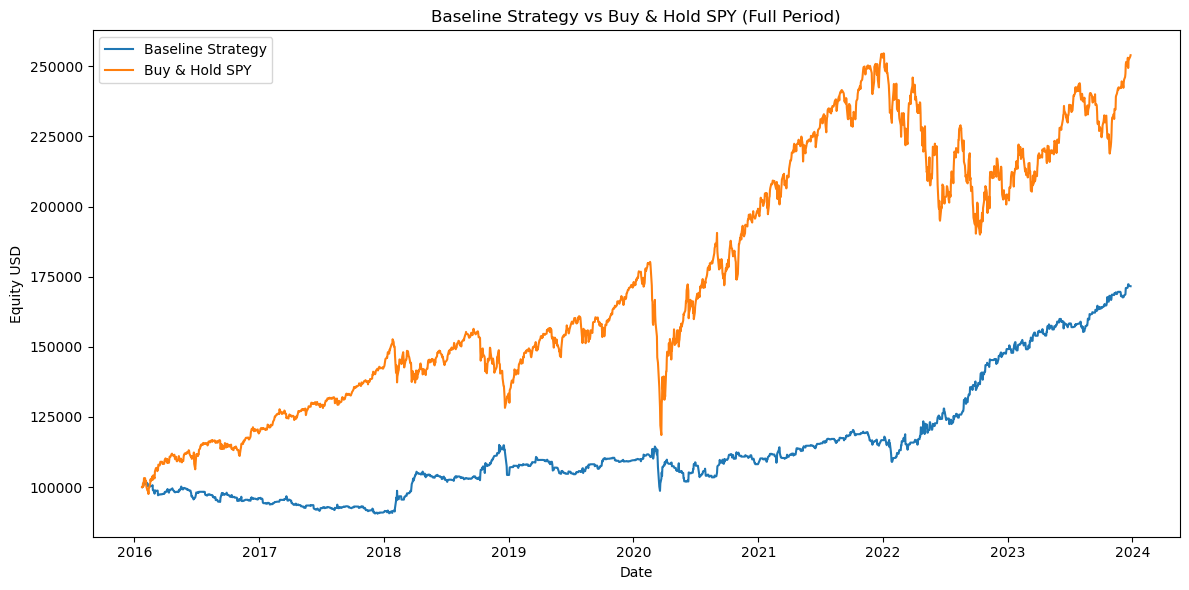

In [27]:
daily_close = df_train.groupby("date")["close"].last().reindex(equity_curve_baseline.index)
spy_ret = daily_close.pct_change().fillna(0.0)

start_date = equity_curve_baseline.index[0] - pd.Timedelta(days=1)
starting_equity = pd.Series([100000.0], index=[start_date])
equity_curve_bh = (1 + spy_ret).cumprod() * 100000.0
equity_curve_bh = pd.concat([starting_equity,equity_curve_bh])

# 2) Plot both
plt.figure(figsize=(12, 6))
plt.plot(equity_curve_baseline.index, equity_curve_baseline.values, label="Baseline Strategy")
plt.plot(equity_curve_bh.index, equity_curve_bh.values, label="Buy & Hold SPY")
plt.xlabel("Date")
plt.ylabel("Equity USD")
plt.title("Baseline Strategy vs Buy & Hold SPY (Full Period)")
plt.legend()
plt.tight_layout()
plt.show()

**We can see that for the in-sample period from 2016 until end of 2023, the buy and hold completely outperforms the baseline strategy. One reason for this might be that our baseline strategy forces an EOD exit while SPY is also traded overnight**

**Now, we will also check the performance of the improved versions of the baseline strategy:**
- current band + vwap
- current band + vwap + dynamc resizing

In [28]:
trades_refined = execute_strategy(df_train_signals)
net_returns_series_refined = calculate_pnl(trades_refined, raw_df = df_train,sizing_type='fixed')
net_returns_series_dynamic = calculate_pnl(trades_refined, raw_df = df_train)

equity_curve_refined = equity_curve(net_returns_series_refined,100000)
equity_curve_dynamic = equity_curve(net_returns_series_dynamic,100000)

In [29]:
# total return from baseline with current band + vwap
print(equity_curve_refined.head(1))
print(equity_curve_refined.tail(1))

2016-01-24    100000.0
dtype: float64
2023-12-27    254772.223195
dtype: float64


In [30]:
# total return from baseline with current band + vwap + dynamic sizing
print(equity_curve_dynamic.head(1))
print(equity_curve_dynamic.tail(1))

2016-01-24    100000.0
dtype: float64
2023-12-27    489054.043008
dtype: float64


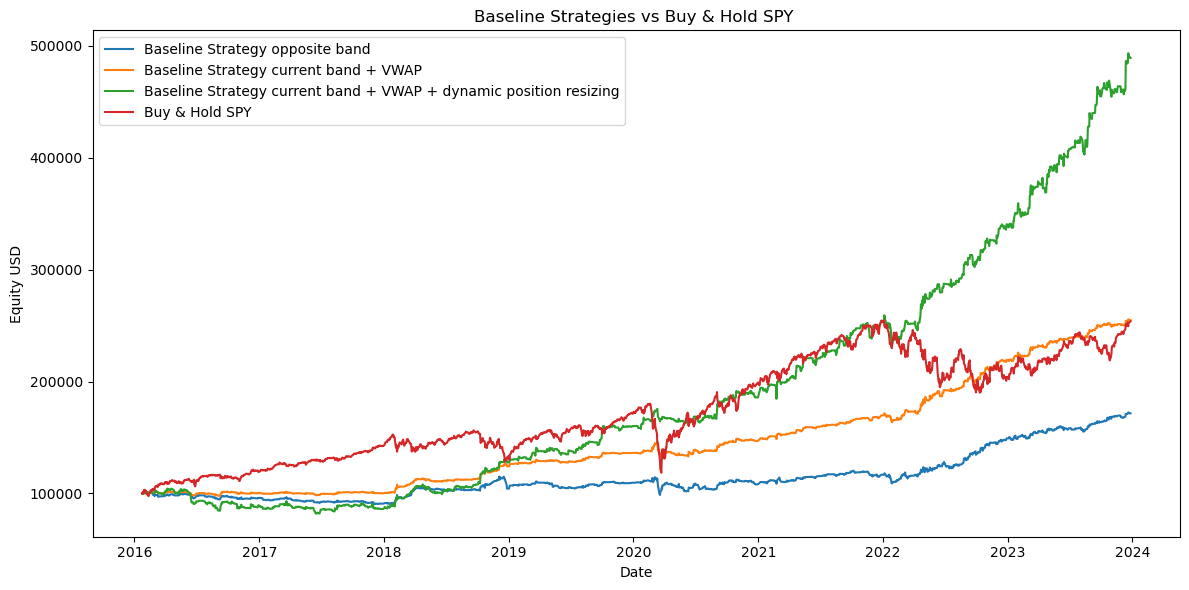

In [31]:
# Plot all 4 curves
plt.figure(figsize=(12, 6))

plt.plot(equity_curve_baseline.index, equity_curve_baseline.values, label="Baseline Strategy opposite band")
plt.plot(equity_curve_refined.index, equity_curve_refined.values, label="Baseline Strategy current band + VWAP ")
plt.plot(equity_curve_dynamic.index, equity_curve_dynamic.values, label="Baseline Strategy current band + VWAP + dynamic position resizing")
plt.plot(equity_curve_bh.index, equity_curve_bh.values, label="Buy & Hold SPY")
plt.xlabel("Date")
plt.ylabel("Equity USD")
plt.title("Baseline Strategies vs Buy & Hold SPY ")
plt.legend()
plt.tight_layout()
plt.show()

**The dynamic position resizing model achieved the highest terminal wealth of about 500,000 USD. The green curve shows how the vwap-anchored stops with volatility-based leverage allowed the strategy to significantly gain advantage against the benchmark during 2022-2023.**

In [32]:
# function: calculates annualized return, annualized volatility, sharpe ratio
# inputs:
#  returns_series: pandas series of daily net returns.
#  rf: risk-free rate. default is zero

def calculate_metrics(returns_series, rf=0):

    # clean data
    daily_returns = returns_series.dropna().astype(float)
    trading_days_py = 252 
    
    # annualized return
    total_period_return = (1 + daily_returns).prod()
    n_days = len(daily_returns)
    ann_return = total_period_return ** (trading_days_py / n_days) - 1
    
    # annualized volatility
    # st dev of daily returns scaled to an annual basis.
    daily_vol = daily_returns.std()
    ann_vol = daily_vol * np.sqrt(trading_days_py)
    
    # Sharpe Ratio (annualized)
    mean_daily_excess_ret = daily_returns.mean() - (rf / trading_days_py)
    
    if daily_vol > 0:
        sharpe = (mean_daily_excess_ret / daily_vol) * np.sqrt(trading_days_py)
    else:
        sharpe = np.nan
        
    metrics = {
        "Annualized Return": float(np.round(ann_return,decimals=2)), 
        "Annualized Volatility": float(np.round(ann_vol,decimals=2)),
        "Sharpe Ratio": float(np.round(sharpe,decimals=2)),
    }
    
    return metrics

In [33]:
print("Evaluation metrics baseline strategy (opposite band):")
print(calculate_metrics(net_returns_series_baseline))
print("Evaluation metrics baseline strategy (current band + vwap)")
print(calculate_metrics(net_returns_series_refined))
print("Evaluation metrics baseline strategy (current band + vwap + dynamic resizing)")
print(calculate_metrics(net_returns_series_dynamic))

Evaluation metrics baseline strategy (opposite band):
{'Annualized Return': 0.07, 'Annualized Volatility': 0.09, 'Sharpe Ratio': 0.77}
Evaluation metrics baseline strategy (current band + vwap)
{'Annualized Return': 0.13, 'Annualized Volatility': 0.07, 'Sharpe Ratio': 1.75}
Evaluation metrics baseline strategy (current band + vwap + dynamic resizing)
{'Annualized Return': 0.22, 'Annualized Volatility': 0.13, 'Sharpe Ratio': 1.59}


In [34]:
metrics_base = calculate_metrics(net_returns_series_baseline)
metrics_ref  = calculate_metrics(net_returns_series_refined)
metrics_dyn  = calculate_metrics(net_returns_series_dynamic)

In [35]:
# function to get total return from the final value of the equity curve
def get_total_ret(equity_series):
    return (equity_series.iloc[-1] / equity_series.iloc[0]) - 1

In [36]:
results_list = [
    {
        "Strategy": "Baseline",
        "Stop": "Opp. Band",
        "Size": "100%",
        "Total Return": f"{get_total_ret(equity_curve_baseline):.1%}",
        "Ann. return": f"{metrics_base['Annualized Return']:.1%}",
        "Vol": f"{metrics_base['Annualized Volatility']:.1%}",
        "Sharpe": f"{metrics_base['Sharpe Ratio']:.2f}"
    },
    {
        "Strategy": "Refined",
        "Stop": "Curr. Band + VWAP",
        "Size": "100%",
        "Total Return": f"{get_total_ret(equity_curve_refined):.1%}",
        "Ann. return": f"{metrics_ref['Annualized Return']:.1%}",
        "Vol": f"{metrics_ref['Annualized Volatility']:.1%}",
        "Sharpe": f"{metrics_ref['Sharpe Ratio']:.2f}"
    },
    {
        "Strategy": "Dynamic",
        "Stop": "Curr. Band + VWAP",
        "Size": "Dynamic (Max 4x)",
        "Total Return": f"{get_total_ret(equity_curve_dynamic):.1%}",
        "Ann. return": f"{metrics_dyn['Annualized Return']:.1%}",
        "Vol": f"{metrics_dyn['Annualized Volatility']:.1%}",
        "Sharpe": f"{metrics_dyn['Sharpe Ratio']:.2f}"
    }
]

df_results = pd.DataFrame(results_list)
print(df_results.to_string(index=False))

Strategy              Stop             Size Total Return Ann. return   Vol Sharpe
Baseline         Opp. Band             100%        71.6%        7.0%  9.0%   0.77
 Refined Curr. Band + VWAP             100%       154.8%       13.0%  7.0%   1.75
 Dynamic Curr. Band + VWAP Dynamic (Max 4x)       389.1%       22.0% 13.0%   1.59


**We observe that the highest annualized return is achieved by the strategy with dynamic resizing, while the current band+vwap strategy has the highest risk-adjusted return**

**Here, we will try to find the most optimal values for lookback, VM and volatility target. Using the nested loop, we can find the best combination of parameters to test out of sample**

In [37]:
# Testing various values for lookback, VM and volatility target on train sample

lookbacks = [14, 30, 90] 
vms = [1.0, 1.2, 1.5]
vol_targets = [0.01, 0.02, 0.03]

sweep_results = []

for i in lookbacks:
    # generate signals once per lookback 
    sig_df = generate_signals(df_train, lookback=i, vm=1.0) 
    
    for j in vms:
       
        sig_df['upper_bound'] = sig_df['base_upper'] * (1 + j * sig_df['sigma'])
        sig_df['lower_bound'] = sig_df['base_lower'] * (1 - j * sig_df['sigma'])
        
        # execute the strategy
        trades_df = execute_strategy(sig_df, stop_type='refined')
        
        for target in vol_targets:
            # calculate metrics
            net_rets = calculate_pnl(trades_df, df_train, sizing_type='dynamic', target_vol=target)
            metrics = calculate_metrics(net_rets)
            
            # store results
            sweep_results.append({
                "Lookback": i,
                "VM": j,
                "VolTarget": target,
                "AnnRet": metrics["Annualized Return"],
                "Sharpe": metrics["Sharpe Ratio"]
            })

# Convert to DataFrame for easy analysis
df_sweep = pd.DataFrame(sweep_results)
print(df_sweep.sort_values("Sharpe", ascending=False).head(10))

    Lookback   VM  VolTarget  AnnRet  Sharpe
2         14  1.0       0.03    0.35    1.80
20        90  1.0       0.03    0.34    1.75
8         14  1.5       0.03    0.24    1.66
5         14  1.2       0.03    0.29    1.66
23        90  1.2       0.03    0.27    1.62
1         14  1.0       0.02    0.22    1.59
17        30  1.5       0.03    0.24    1.58
14        30  1.2       0.03    0.27    1.57
19        90  1.0       0.02    0.21    1.53
4         14  1.2       0.02    0.19    1.50


In [38]:
df_train_signals_best = generate_signals(df_train,lookback=14,vm = 1.0 )
trades_best = execute_strategy(df_train_signals_best, stop_type='refined')
net_returns_series_best = calculate_pnl(trades_best, df_train, target_vol=0.03)
equity_curve_best = equity_curve(net_returns_series_best,100000)



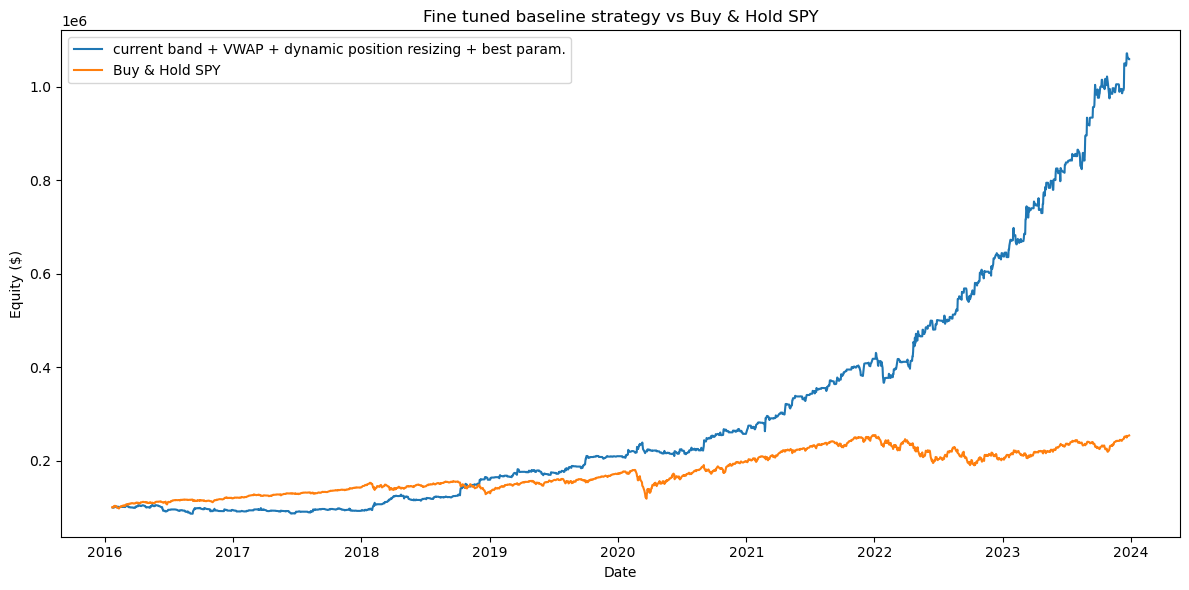

In [39]:
# Plot the fine-tuned baseline version against SPY
plt.figure(figsize=(12, 6))

plt.plot(equity_curve_best.index, equity_curve_best.values, label="current band + VWAP + dynamic position resizing + best param.")
plt.plot(equity_curve_bh.index, equity_curve_bh.values, label="Buy & Hold SPY")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.title("Fine tuned baseline strategy vs Buy & Hold SPY")
plt.legend()
plt.tight_layout()
plt.show()

**We can see that from 2019 onwards, the fine-tuned baseline strategy gains a drastically higher return than the benchmark**

In [40]:
print("Evaluation metrics for fine-tuned baseline strategy:")
print(calculate_metrics(net_returns_series_best))

Evaluation metrics for fine-tuned baseline strategy:
{'Annualized Return': 0.35, 'Annualized Volatility': 0.18, 'Sharpe Ratio': 1.8}


### **Run the fine-tuned strategy out of sample**

In [41]:
df_TEST_signals = generate_signals(df_test,lookback=14,vm = 1.0 )
trades_TEST = execute_strategy(df_TEST_signals, stop_type='refined')
net_returns_series_TEST = calculate_pnl(trades_TEST, df_TEST_signals, target_vol=0.03)
equity_curve_TEST = equity_curve(net_returns_series_TEST,100000)

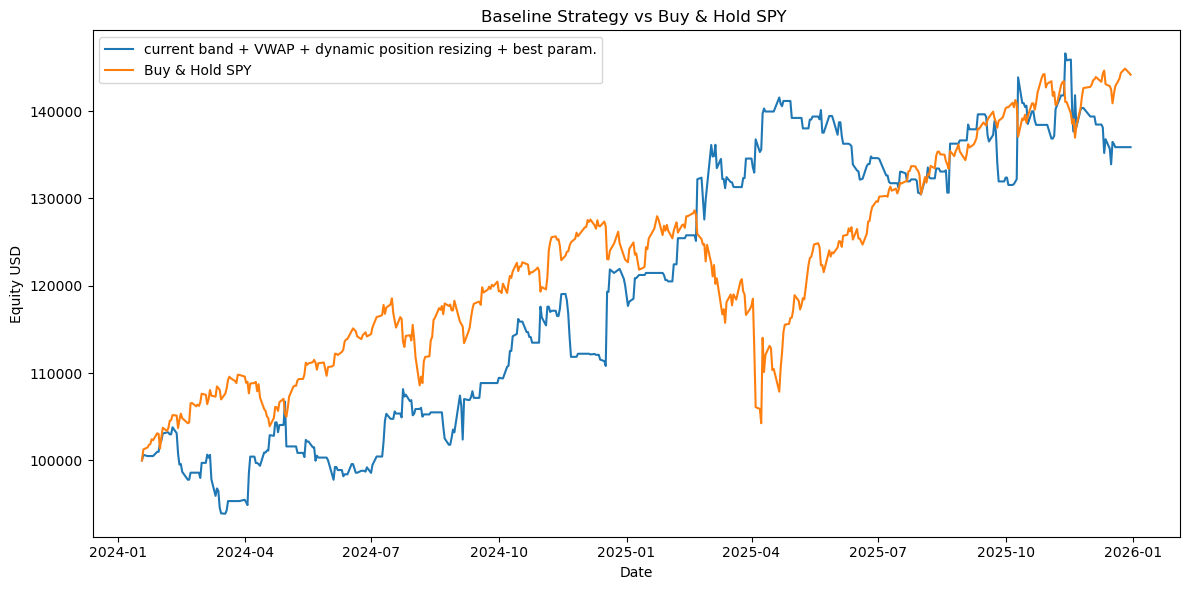

In [42]:
daily_close_TEST = df_test.groupby("date")["close"].last().reindex(equity_curve_TEST.index)
spy_ret_TEST = daily_close_TEST.pct_change().fillna(0.0)

equity_curve_bh_TEST = (1 + spy_ret_TEST).cumprod() * 100000.0

plt.figure(figsize=(12, 6))


plt.plot(equity_curve_TEST.index, equity_curve_TEST.values, label="current band + VWAP + dynamic position resizing + best param.")
plt.plot(equity_curve_bh_TEST.index, equity_curve_bh_TEST.values, label="Buy & Hold SPY")
plt.xlabel("Date")
plt.ylabel("Equity USD")
plt.title("Baseline Strategy vs Buy & Hold SPY ")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
print(calculate_metrics(net_returns_series_TEST))

{'Annualized Return': 0.17, 'Annualized Volatility': 0.18, 'Sharpe Ratio': 0.96}


**The out-of-sample results are not as satisfying. The benchmark finishes above our strategy at the end of 2025. We only see better performance of our strategy during the market dip in Q2, 2025. The Sharpe Ratio of 0.96 tells us that the risk-adjusted returns of the strategy are not much higher than the risk-free rate**

# Step 4: model extension


**As an extension of the baseline, I will use the Relative Volume (RVOL) extension. This is a filter that requires a price breakout to be confirmed by a significant increase in trading activity. I decided to implement this logic because price movements on low volume are often retail noise. In contrast, moves backed by high RVOL (e.g. 1.5x the historical average for that specific minute) could be an indicator for institutional participation. The strategy aims to avoid some of the noise that triggers stop-losses in the baseline model.**


In [44]:

# rvol serves as an additional filter to confirm abnormal demand/supply imbalances


def generate_signals_rvol(df, lookback, vm):

    # sort by date and time to ensure rolling(14) 
    # gets the 14 most recent previous days for that specific minute.
    df = df.sort_values(['date', 'minute_index'])

    # daily open price 
    df['open_price'] = df.groupby('date')['open'].transform('first')

    # compute intraday return from open and its absolute value
    df['ret_from_open'] = df['close'] / df['open_price'] - 1
    df['abs_move'] = df['ret_from_open'].abs()

    # compute sigma
    df['sigma'] = (
        df.groupby('minute_index')['abs_move']
        .transform(lambda x: x.shift(1).rolling(lookback).mean())
    )

    # we use the previous day's close to adjust boundaries for overnight gaps.
    daily_close = df.groupby('date')['close'].last()
    prev_close_map = daily_close.shift(1)
    df['prev_close'] = df['date'].map(prev_close_map)

    # noise area boundaries
    # upper: max of open/prev_close + (VM * sigma)
    # lower: min of open/prev_close - (VM * sigma)
    df['base_upper'] = df[['open_price', 'prev_close']].max(axis=1)
    df['base_lower'] = df[['open_price', 'prev_close']].min(axis=1)

    df['upper_bound'] = df['base_upper'] * (1 + vm * df['sigma'])
    df['lower_bound'] = df['base_lower'] * (1 - vm * df['sigma'])

    # RVOL
    # calculaet the normal volume for this specific minute index over 14 days
    df['avg_vol_min'] = (
        df.groupby('minute_index')['volume']
        .transform(lambda x: x.shift(1).rolling(window=14).mean())
    )

    # 2. Calculate the RVOL ratio (today/avg)
    # We fill NaN with 1.0 so the strategy treats the warm-up period as normal volume
    df['rvol'] = (df['volume'] / df['avg_vol_min']).fillna(1.0)

    # remove rows where we don't have enough lookback data yet
    return df.dropna(subset=['sigma', 'prev_close']).copy()

In [45]:

# rvol filter: introduces a requirement that current volume must be 
#significantly higher than the historical average for that minute.
# dual-condition entry: requires both a price breakout from the noise area 
# and the rvol threshold to be met simultaneously

def execute_strategy_rvol(signal_df, stop_type='refined', rvol_threshold=1.5):
    df = signal_df.copy()
    
    is_dec_time = (df['minute_index'] >= 30) & (df['minute_index'] % 30 == 0)
    is_eod = (df['minute_index'] == 390) 

    # 2. RVOL Condition: only trade if volume is significantly higher than normal
    is_high_vol = df['rvol'] >= rvol_threshold

    # entry signals now requiring both price breakout AND high volume
    df['raw_signal'] = 0
    df.loc[is_dec_time & is_high_vol & (df['close'] > df['upper_bound']), 'raw_signal'] = 1
    df.loc[is_dec_time & is_high_vol & (df['close'] < df['lower_bound']), 'raw_signal'] = -1

    # stop-loss
    if stop_type == 'baseline':
        sl_long = (df['close'] < df['lower_bound'])
        sl_short = (df['close'] > df['upper_bound'])
    else:
        
        stop_long_thresh = df[['upper_bound', 'vwap_anchored']].max(axis=1)
        stop_short_thresh = df[['lower_bound', 'vwap_anchored']].min(axis=1)
        sl_long = (df['close'] < stop_long_thresh)
        sl_short = (df['close'] > stop_short_thresh)

    # ffill entries and stops
    df['stop_event'] = np.nan
    df.loc[is_dec_time & (sl_long | sl_short), 'stop_event'] = 0
    df['combined_event'] = df['raw_signal'].mask(df['raw_signal'] == 0, df['stop_event'])
    
    df['position'] = df.groupby('date')['combined_event'].ffill().fillna(0).astype(int)
    df.loc[is_eod, 'position'] = 0
    df["exec_minute_index"] = df["minute_index"] + 1

    return df

In [46]:
# prepare signals
df_train_rvol = generate_signals_rvol(df_train, lookback=14, vm=1.0)

# execute with a 1.5x RVOL threshold 
trades_rvol = execute_strategy_rvol(df_train_rvol, stop_type='refined', rvol_threshold=1.5)

# calculate pnl
net_returns_rvol = calculate_pnl(trades_rvol, raw_df=df_train, sizing_type='dynamic', target_vol=0.03)

equity_curve_rvol = equity_curve(net_returns_rvol,100000)

# 4. Evaluate
metrics_rvol = calculate_metrics(net_returns_rvol)
print(metrics_rvol)

{'Annualized Return': 0.14, 'Annualized Volatility': 0.12, 'Sharpe Ratio': 1.18}


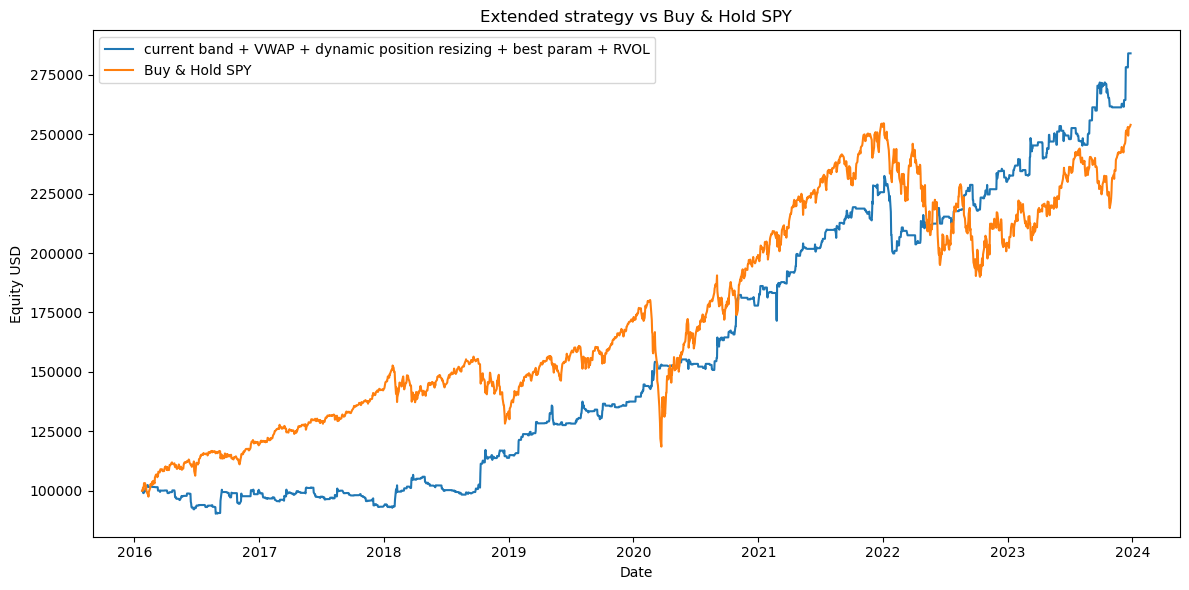

In [47]:
# 2) Plot with RVOL
plt.figure(figsize=(12, 6))


plt.plot(equity_curve_rvol.index, equity_curve_rvol.values, label="current band + VWAP + dynamic position resizing + best param + RVOL")
plt.plot(equity_curve_bh.index, equity_curve_bh.values, label="Buy & Hold SPY")
plt.xlabel("Date")
plt.ylabel("Equity USD")
plt.title("Extended strategy vs Buy & Hold SPY")
plt.legend()
plt.tight_layout()
plt.show()

**Unlike the buy-and-hold approach, the RVOL-filtered strategy shows smoother growth during the volatile 2020–2022 period.By the end of 2023, the refined model with the RVOL extension achieves a terminal wealth of approximately USD 285,000, successfully outperforming the SPY's terminal value of around $255,000.**

In [48]:
## find best parameters (thresholds) to tune ## 
sig_df_rvol = generate_signals_rvol(df_train, lookback=14, vm=1.0)

# thresholds to test: from 1.0 (baseline) to 2.5 (extreme institutional flow)
rvol_thresholds = [1.0, 1.2, 1.5, 1.8, 2.0, 2.5]
rvol_sweep_results = []

for threshold in rvol_thresholds:
    trades_rvol = execute_strategy_rvol(sig_df_rvol, stop_type='refined', rvol_threshold=threshold)
    
    net_rets = calculate_pnl(trades_rvol, raw_df=df_train, sizing_type='dynamic', target_vol=0.03)
    
    metrics = calculate_metrics(net_rets)

    rvol_sweep_results.append({
        "RVOL_Threshold": threshold,
        "Sharpe Ratio": metrics["Sharpe Ratio"],
        "Annualized return": metrics["Annualized Return"],
    })

# Convert to DataFrame
df_rvol_sweep = pd.DataFrame(rvol_sweep_results)
print(df_rvol_sweep.to_string(index=False))

 RVOL_Threshold  Sharpe Ratio  Annualized return
            1.0          1.29               0.19
            1.2          1.17               0.16
            1.5          1.18               0.14
            1.8          1.03               0.10
            2.0          0.75               0.07
            2.5          0.86               0.07


**Based on the train sample, we see that 1.0 is the most optimal threshold parameter in terms of Annualized return and Sharpe ratio**

### Out-of-sample evaluation

In [49]:
# Best RVOL model
best_rvol_threshold = 1.0
df_TEST_signals_rvol = generate_signals_rvol(df_test,lookback=14,vm = 1.0 )
trades_TEST_rvol = execute_strategy_rvol(df_TEST_signals_rvol, stop_type='refined',rvol_threshold=best_rvol_threshold)
net_returns_series_rvol_TEST = calculate_pnl(trades_TEST_rvol, df_test, target_vol=0.03)
equity_curve_rvol_TEST = equity_curve(net_returns_series_rvol_TEST,100000)

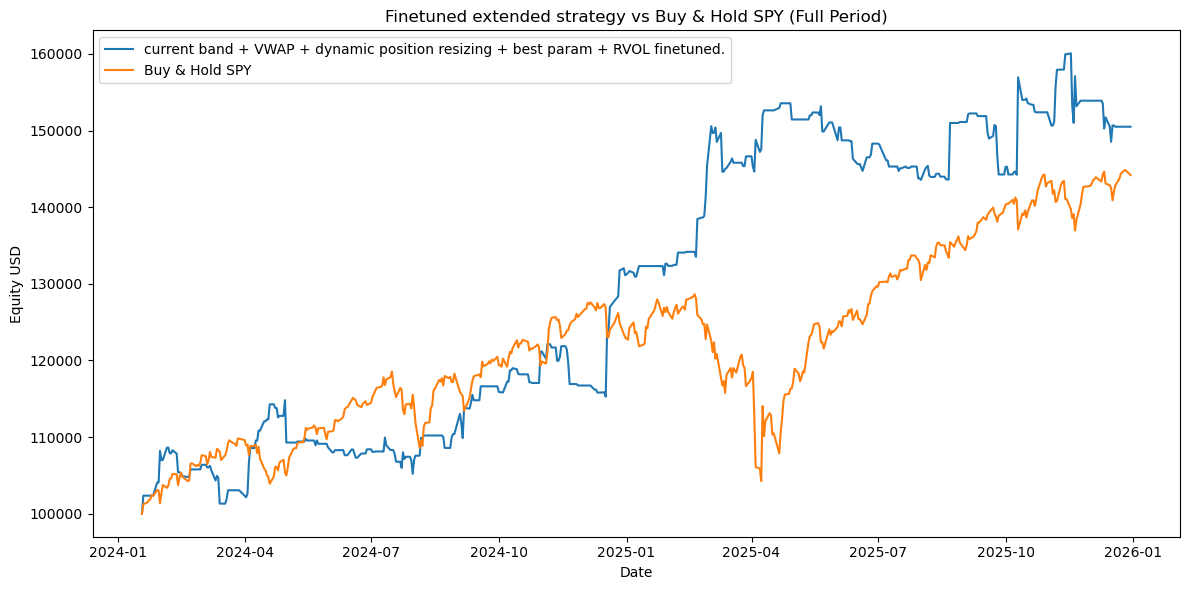

In [50]:
daily_close_TEST = df_test.groupby("date")["close"].last().reindex(equity_curve_rvol_TEST.index)
spy_ret_TEST = daily_close_TEST.pct_change().fillna(0.0)

equity_curve_bh_TEST = (1 + spy_ret_TEST).cumprod() * 100000.0

plt.figure(figsize=(12, 6))


plt.plot(equity_curve_rvol_TEST.index, equity_curve_rvol_TEST.values, label="current band + VWAP + dynamic position resizing + best param + RVOL finetuned.")
plt.plot(equity_curve_bh_TEST.index, equity_curve_bh_TEST.values, label="Buy & Hold SPY")
plt.xlabel("Date")
plt.ylabel("Equity USD")
plt.title("Finetuned extended strategy vs Buy & Hold SPY (Full Period)")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
print(calculate_metrics(net_returns_series_rvol_TEST))

{'Annualized Return': 0.24, 'Annualized Volatility': 0.17, 'Sharpe Ratio': 1.34}


**The RVOL-filtered strategy succesfully outperforms the benchmark out of sample. We see that the strategy generates a risk-adjusted return above the risk-free rate and that it performs exceptionally well during the market dip in April 2025**

**The primary edge comes from finding the difference between standard price fluctuations and abnormal supply/demand imbalances that are backed by high liquidity and volume.The model's idea is to avoids the noisy price action typical of fluctuations that are driven by retail. This ensures that the strategy only commits when there is a strong probability that the supply/demand imbalance is powerful enough to sustain a profitable intraday trend.**

**Currently the strategy forces an exit at the market close which systematically excludes the overnight risk premium. The model can be expanded to where it could identify days where the overnight gap is so significant that it indicates a structural shift in sentiment. This would allow for immediate entry at the 9:30 open rather than waiting for the 10:00 decision. Such improvement would enable the strategy to capture the market's long-term upward drift more effectively.**